# buffer_capacity sweep — AC learning curves

This notebook **trains Actor-Critic models from inside the notebook** for multiple values of `buffer_capacity`,
then plots learning curves.

## Outputs
For each capacity `C`, it writes into:
- `../artifacts/buffer_capacity_sweep/buf_C/`

Inside each folder you get:
- `train_log_actor_critic.csv`
- `actor_critic_model.pt`
- `checkpoints/`

## Notes
Training from inside a notebook can take a long time.
Set `RUN_TRAINING=False` to only re-plot existing CSVs.

In [1]:
from __future__ import annotations

from pathlib import Path
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# ------------------- user params -------------------
BUFFER_CAPACITIES = [256, 1024, 5000, 10000]
STEPS_PER_RUN = 500_000  # set to 500_000 for full runs
SEED = 420
DEVICE = 'cpu'
RUN_TRAINING = True  # set False to only re-plot existing CSVs
WINDOW = 100
# ---------------------------------------------------

# Determine project root so `python -m run.train` works even if the notebook cwd is `analysis/`.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'run').exists() and (PROJECT_ROOT.parent / 'run').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

BASE_OUTDIR = PROJECT_ROOT / 'artifacts' / 'buffer_capacity_sweep'
BASE_OUTDIR.mkdir(parents=True, exist_ok=True)

results: dict[int, pd.DataFrame] = {}


In [2]:
def train_capacity(buffer_capacity: int) -> Path:
    run_dir = BASE_OUTDIR / f'buf_{buffer_capacity}'
    run_dir.mkdir(parents=True, exist_ok=True)

    log_csv = run_dir / 'train_log_actor_critic.csv'

    if not RUN_TRAINING and log_csv.exists():
        print(f"[skip] buffer_capacity={buffer_capacity} (CSV exists): {log_csv}")
        return run_dir

    print(f"[train] buffer_capacity={buffer_capacity} steps={STEPS_PER_RUN} -> {run_dir}")

    cmd = [
        sys.executable,
        '-m', 'run.train',
        '--agent', 'actor_critic',
        '--steps', str(STEPS_PER_RUN),
        '--seed', str(SEED),
        '--device', DEVICE,
        '--buffer-capacity', str(buffer_capacity),
        '--artifacts-dir', str(run_dir),
    ]

    subprocess.run(cmd, check=True, cwd=str(PROJECT_ROOT))

    if not log_csv.exists():
        raise FileNotFoundError(f"Expected CSV not found after training: {log_csv}")

    return run_dir


In [3]:
for cap in BUFFER_CAPACITIES:
    run_dir = train_capacity(cap)
    df = pd.read_csv(run_dir / 'train_log_actor_critic.csv')
    results[int(cap)] = df

print('Loaded runs:', sorted(results.keys()))
for cap, df in sorted(results.items()):
    print(f'- buffer_capacity={cap}: rows={len(df)} columns={list(df.columns)}')


[train] buffer_capacity=256 steps=500000 -> /Users/vasilij/Documents/RL_proj4/HorizontalPong/artifacts/buffer_capacity_sweep/buf_256
pygame-ce 2.5.7 (SDL 2.32.10, Python 3.14.0)
Starting Actor-Critic training for 500000 steps...
Step: 6168/500000 | Episode: 100 | Avg Reward: -74.000 | Avg Hits: 0.26 | Critic: 0.0000 | Actor: 0.0000 | Entropy: 0.0000 | GradNorm: 0.0000 | LR: 0.00e+00
Step: 11837/500000 | Episode: 200 | Avg Reward: -78.000 | Avg Hits: 0.22 | Critic: 0.0000 | Actor: 0.0000 | Entropy: 0.0000 | GradNorm: 0.0000 | LR: 0.00e+00
Step: 18434/500000 | Episode: 300 | Avg Reward: -71.000 | Avg Hits: 0.29 | Critic: 0.0000 | Actor: 0.0000 | Entropy: 0.0000 | GradNorm: 0.0000 | LR: 0.00e+00
Step: 25149/500000 | Episode: 400 | Avg Reward: -70.000 | Avg Hits: 0.30 | Critic: 0.0000 | Actor: 0.0000 | Entropy: 0.0000 | GradNorm: 0.0000 | LR: 0.00e+00
Step: 31774/500000 | Episode: 500 | Avg Reward: -74.000 | Avg Hits: 0.26 | Critic: 0.0000 | Actor: 0.0000 | Entropy: 0.0000 | GradNorm: 0.00

In [4]:
def ensure_episode(df: pd.DataFrame) -> pd.DataFrame:
    if 'episode' in df.columns:
        return df
    df = df.copy()
    df['episode'] = np.arange(1, len(df) + 1)
    return df


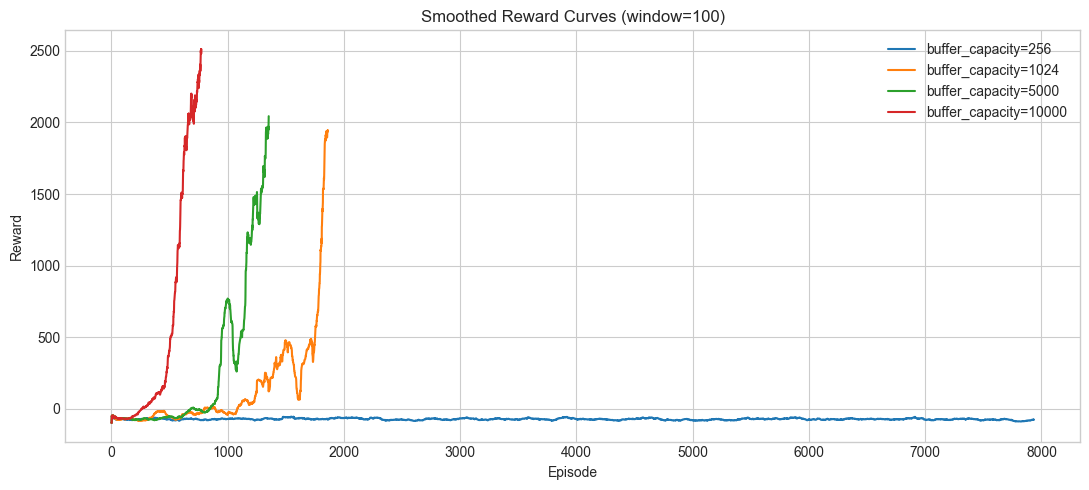

In [5]:
# Smoothed reward curves
plt.figure(figsize=(11, 5))
for cap, df in sorted(results.items()):
    df = ensure_episode(df)
    if 'reward' not in df.columns:
        continue
    smooth = df['reward'].rolling(WINDOW, min_periods=1).mean()
    plt.plot(df['episode'], smooth, label=f'buffer_capacity={cap}')

plt.title(f'Smoothed Reward Curves (window={WINDOW})')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()
plt.tight_layout()
plt.show()


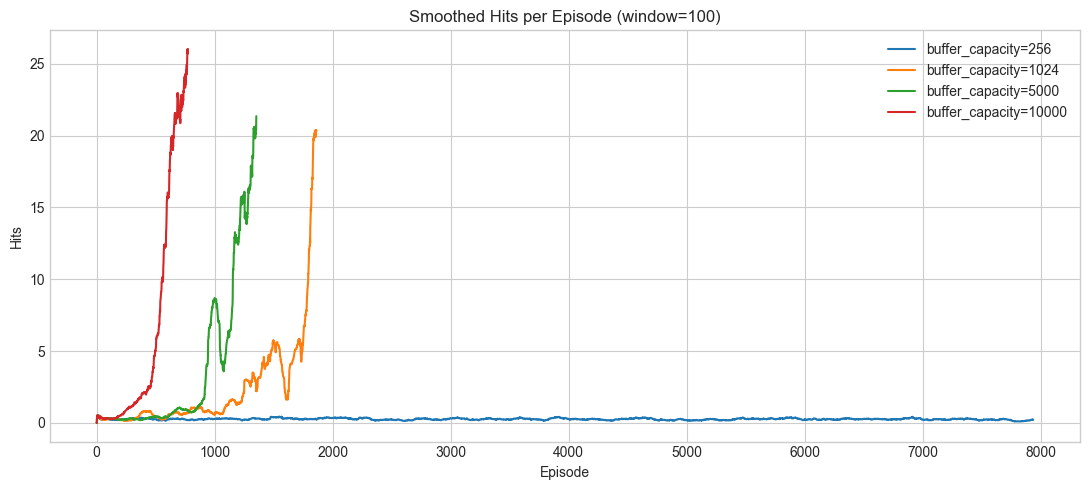

In [6]:
# Smoothed hits curves (if available)
if any('hits' in df.columns for df in results.values()):
    plt.figure(figsize=(11, 5))
    plotted = False
    for cap, df in sorted(results.items()):
        if 'hits' not in df.columns:
            continue
        df = ensure_episode(df)
        smooth = df['hits'].rolling(WINDOW, min_periods=1).mean()
        plt.plot(df['episode'], smooth, label=f'buffer_capacity={cap}')
        plotted = True

    if plotted:
        plt.title(f'Smoothed Hits per Episode (window={WINDOW})')
        plt.xlabel('Episode')
        plt.ylabel('Hits')
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("No 'hits' column found in loaded logs.")


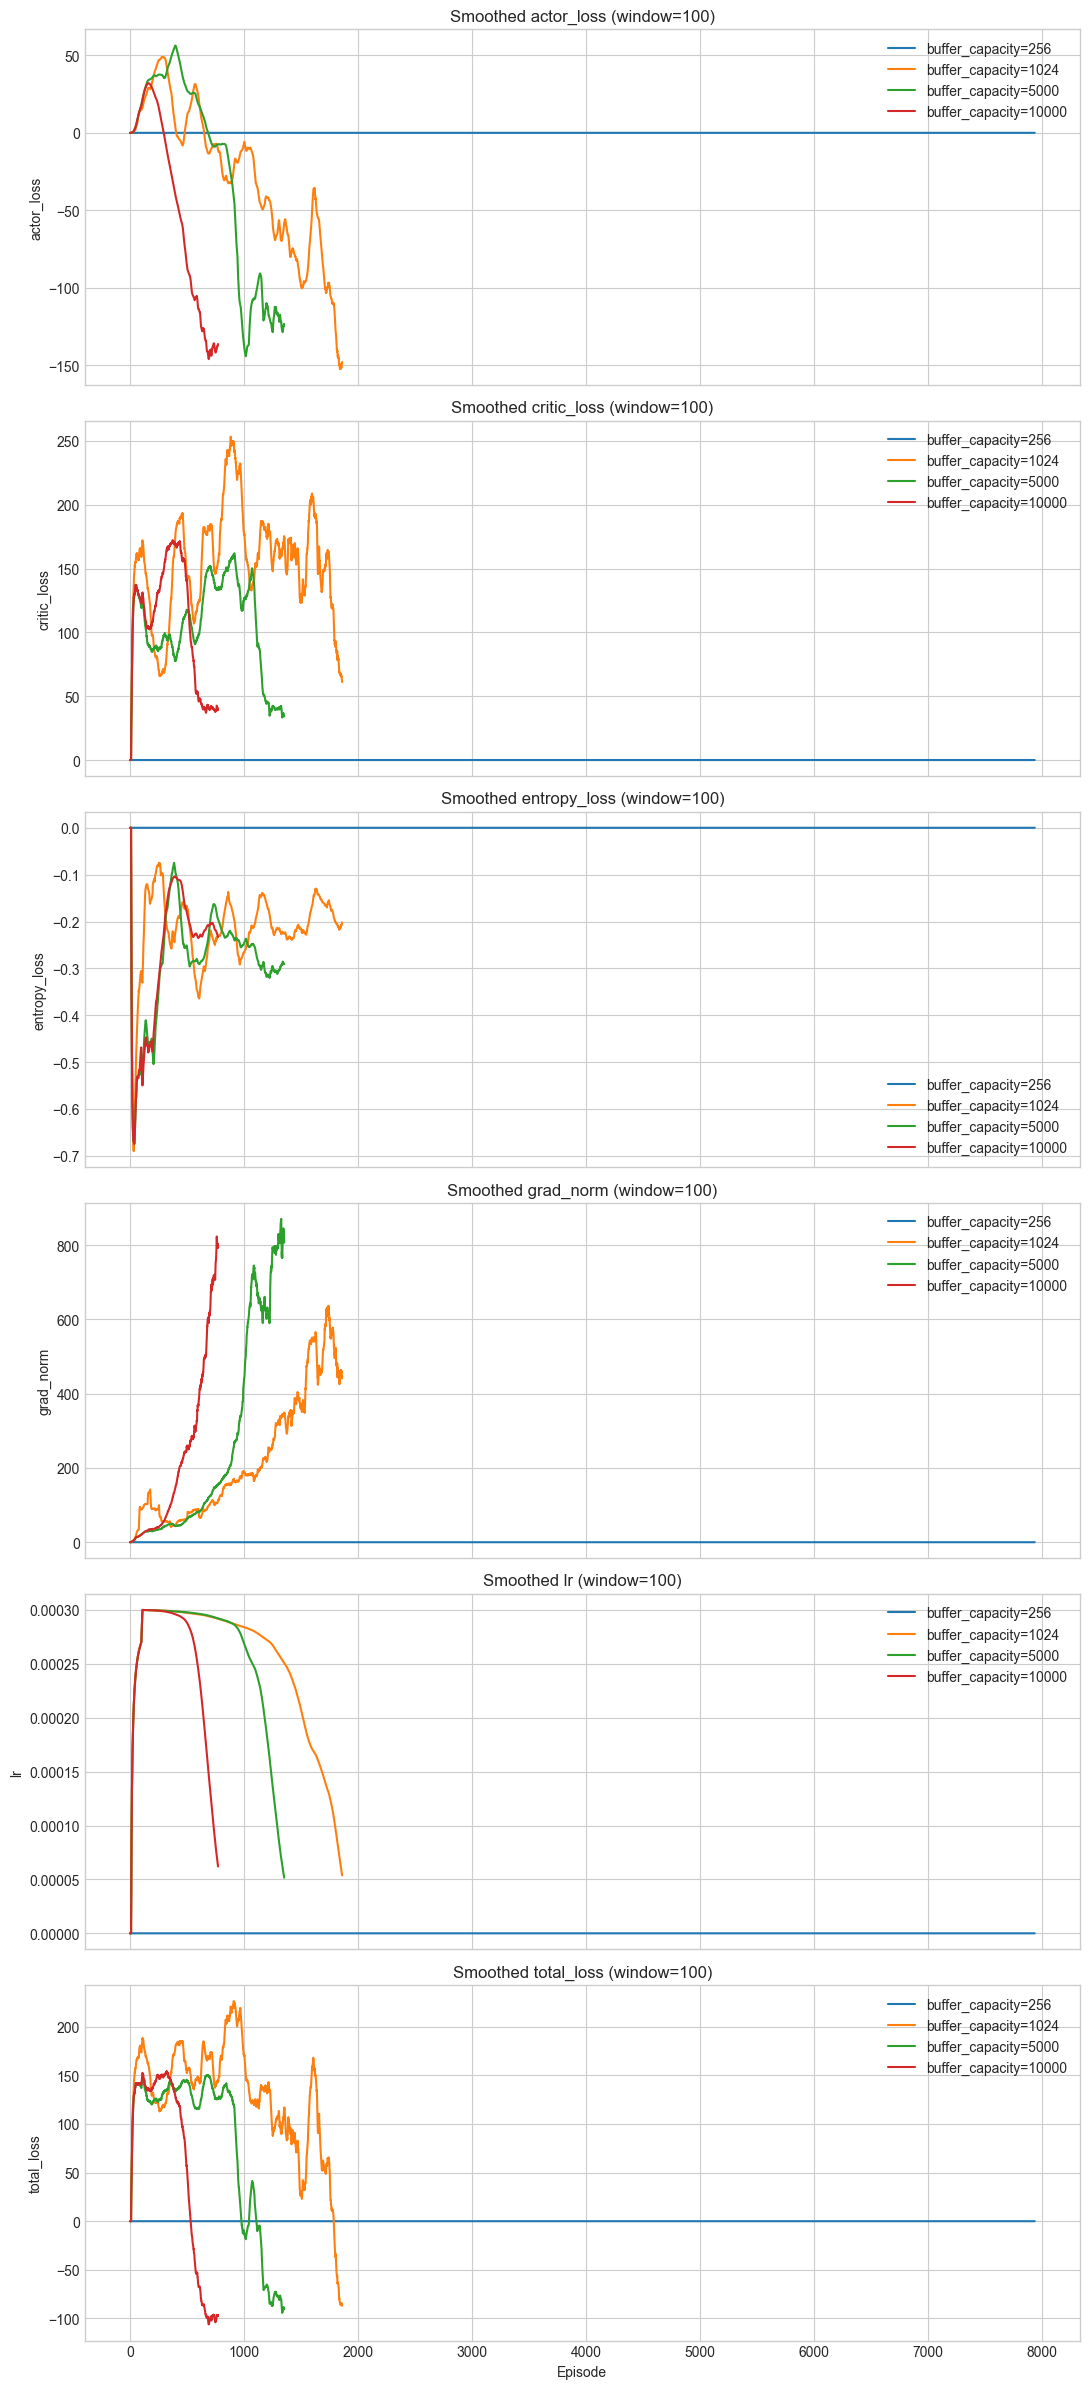

In [7]:
# Loss curves (optional)
loss_candidates = ['actor_loss', 'critic_loss', 'total_loss', 'grad_norm', 'entropy_loss', 'lr']
avail = sorted({c for df in results.values() for c in loss_candidates if c in df.columns})

if not avail:
    print('No known loss columns found in loaded logs.')
else:
    n = len(avail)
    fig, axes = plt.subplots(n, 1, figsize=(11, 4 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, avail):
        for cap, df in sorted(results.items()):
            if col not in df.columns:
                continue
            df = ensure_episode(df)
            smooth = df[col].rolling(WINDOW, min_periods=1).mean()
            ax.plot(df['episode'], smooth, label=f'buffer_capacity={cap}')
        ax.set_title(f'Smoothed {col} (window={WINDOW})')
        ax.set_ylabel(col)
        ax.legend()

    axes[-1].set_xlabel('Episode')
    plt.tight_layout()
    plt.show()


In [8]:
# Summary table
rows = []
for cap, df in sorted(results.items()):
    df = ensure_episode(df)
    row = {'buffer_capacity': cap, 'episodes': len(df)}

    for col in ['reward', 'hits', 'critic_loss', 'actor_loss', 'total_loss', 'grad_norm', 'entropy_loss', 'lr']:
        if col in df.columns and len(df) > 0:
            tail = df[col].tail(WINDOW)
            row[f'last{WINDOW}_{col}_mean'] = float(tail.mean())
            row[f'last{WINDOW}_{col}_std'] = float(tail.std(ddof=0))

    rows.append(row)

summary = pd.DataFrame(rows).sort_values('buffer_capacity').reset_index(drop=True)
summary


,buffer_capacity,episodes,last100_reward_mean,last100_reward_std,last100_hits_mean,last100_hits_std,last100_critic_loss_mean,last100_critic_loss_std,last100_actor_loss_mean,last100_actor_loss_std,last100_total_loss_mean,last100_total_loss_std,last100_grad_norm_mean,last100_grad_norm_std,last100_entropy_loss_mean,last100_entropy_loss_std,last100_lr_mean,last100_lr_std
0,256,7935,-77.0,48.692915,0.22,0.460000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1024,1861,1947.0,2171.978591,20.40,21.679483,61.077141,91.919200,-147.970038,67.113775,-86.913085,93.969107,440.938075,568.150543,-0.201882,0.065215,0.000054,0.000019
2,5000,1353,2044.0,2476.179315,21.36,24.621746,34.123586,28.188866,-124.726401,40.643556,-90.631902,49.767839,807.018915,648.739426,-0.290882,0.056549,0.000052,0.000018
3,10000,773,2513.0,2418.539022,26.02,24.069474,39.041365,41.737035,-136.412037,38.148589,-97.393969,58.182901,793.563635,587.805208,-0.232973,0.042836,0.000062,0.000025
